In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers

tf.config.run_functions_eagerly(True)

In [2]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
NUM_CLASSES = 7
EPOCHS = 15

train_dir = r"train"
test_dir  = r"test"

In [3]:
# 1) Генератори даних (аугментація + нормалізація)
# У статті згадується горизонтальне дзеркалення і аугментація для міноритарних класів.
# Тут задаємо типову аугментацію + horizontal_flip=True.
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10
)

# Для тесту/валідації зазвичай тільки нормалізація
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode="grayscale",          # 48x48 grey-scale
    batch_size=BATCH_SIZE,
    class_mode="categorical",        # categorical_crossentropy
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [4]:
# 2) CNN архітектура: 4 Conv шари + 2 Dense (за описом)
model = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    # Conv block 1
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv block 2
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv block 3
    layers.Conv2D(512, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv block 4
    layers.Conv2D(512, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten + 2 fully connected (Dense) layers
    layers.Flatten(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    # Output: Dense + Softmax (7 класів)
    layers.Dense(NUM_CLASSES, activation="softmax")
])

In [5]:
# 3) Компіляція: Adam + categorical_crossentropy + accuracy (як в статті)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 512)         │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 12, 12, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 6, 6, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 4,347,655 (16.58 MB)

 Trainable params: 4,343,687 (16.57 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [6]:
# 4) Навчання: 15 епох (як в статті)
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen
)


Epoch 1/15


D:\ProgramFiles\Python3.10\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
D:\ProgramFiles\Python3.10\lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


449/449 ━━━━━━━━━━━━━━━━━━━━ 456s 1s/step - accuracy: 0.1937 - loss: 2.1720 - val_accuracy: 0.2533 - val_loss: 1.8537
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 412s 917ms/step - accuracy: 0.2399 - loss: 1.9132 - val_accuracy: 0.2871 - val_loss: 1.7623
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 391s 870ms/step - accuracy: 0.2685 - loss: 1.8508 - val_accuracy: 0.3034 - val_loss: 1.7119
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 391s 871ms/step - accuracy: 0.2856 - loss: 1.7989 - val_accuracy: 0.3278 - val_loss: 1.7850
Epoch 5/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 390s 868ms/step - accuracy: 0.3196 - loss: 1.7250 - val_accuracy: 0.3688 - val_loss: 1.6614
Epoch 6/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 390s 869ms/step - accuracy: 0.3406 - loss: 1.6800 - val_accuracy: 0.3312 - val_loss: 1.9727
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 391s 870ms/step - accuracy: 0.3762 - loss: 1.6265 - val_accuracy: 0.4239 - val_loss: 1.5202
Epoch 8/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 391s 870ms/step - accuracy: 0.3847 - loss: 1.5768 

In [7]:
# 5) Оцінювання
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


Test accuracy: 0.5485


In [8]:
model.save("fer_cnn_48x48_grayscale.h5")  # зберігаємо все (включно з оптимізатором)


In [9]:
from tensorflow.keras.models import load_model

model = load_model("fer_cnn_48x48_grayscale.h5")  # містить оптимізатор

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

INITIAL_EPOCHS = 15
TOTAL_EPOCHS = 30

# Колбеки
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("fer_best_model.h5", monitor='val_accuracy', save_best_only=True)
]

# Скомпілювати заново з новим оптимізатором
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Тепер можна продовжити навчання
history2 = model.fit(
    train_gen,
    epochs=30,
    initial_epoch=15,
    validation_data=test_gen,
    callbacks=callbacks
)

# ---- Підсумкова оцінка ----
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Final test accuracy: {test_acc:.4f}")

model.save("fer_cnn_final_30_epochs.h5")

Epoch 16/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.4947 - loss: 1.3272

449/449 ━━━━━━━━━━━━━━━━━━━━ 389s 867ms/step - accuracy: 0.4947 - loss: 1.3271 - val_accuracy: 0.5032 - val_loss: 1.3365
Epoch 17/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.5086 - loss: 1.2906

449/449 ━━━━━━━━━━━━━━━━━━━━ 389s 865ms/step - accuracy: 0.5086 - loss: 1.2906 - val_accuracy: 0.5365 - val_loss: 1.2095
Epoch 18/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 842ms/step - accuracy: 0.5066 - loss: 1.2941

449/449 ━━━━━━━━━━━━━━━━━━━━ 399s 888ms/step - accuracy: 0.5067 - loss: 1.2941 - val_accuracy: 0.5556 - val_loss: 1.1574
Epoch 19/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.5177 - loss: 1.2585

449/449 ━━━━━━━━━━━━━━━━━━━━ 446s 992ms/step - accuracy: 0.5177 - loss: 1.2585 - val_accuracy: 0.5751 - val_loss: 1.1135
Epoch 20/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 450s 1s/step - accuracy: 0.5260 - loss: 1.2438 - val_accuracy: 0.5616 - val_loss: 1.1643
Epoch 21/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 445s 991ms/step - accuracy: 0.5318 - loss: 1.2320 - val_accuracy: 0.5249 - val_loss: 1.2333
Epoch 22/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 446s 992ms/step - accuracy: 0.5363 - loss: 1.2214 - val_accuracy: 0.5691 - val_loss: 1.1380
Epoch 23/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 448s 997ms/step - accuracy: 0.5367 - loss: 1.2225 - val_accuracy: 0.5627 - val_loss: 1.1367
Epoch 24/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 448s 998ms/step - accuracy: 0.5445 - loss: 1.1911 - val_accuracy: 0.5660 - val_loss: 1.1370


Final test accuracy: 0.5751


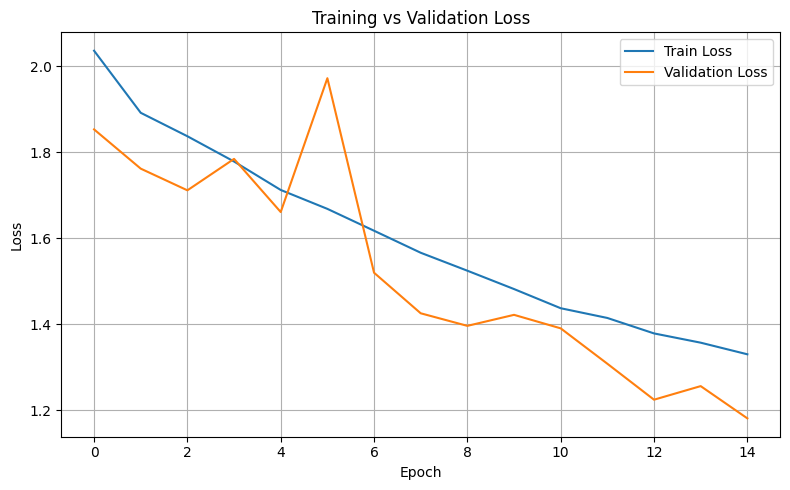

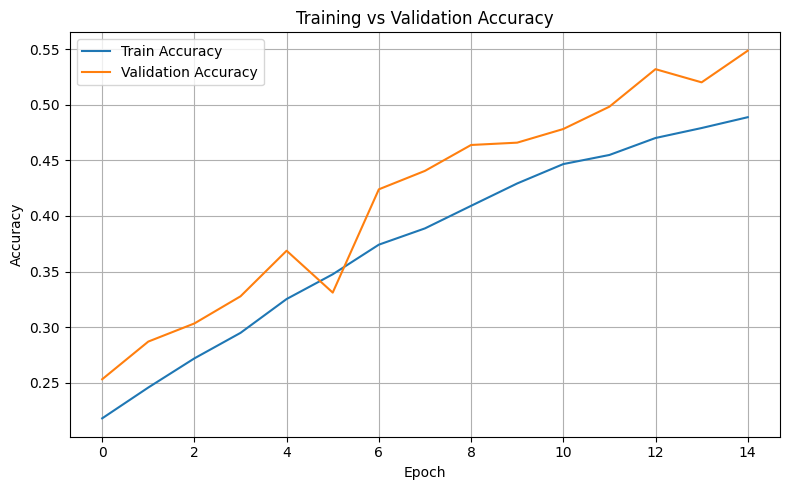

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# --- LOSS ---
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- ACCURACY ---
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

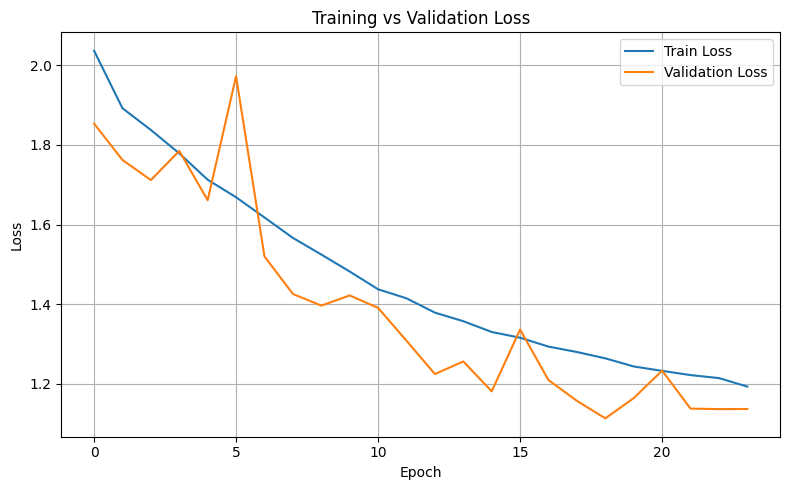

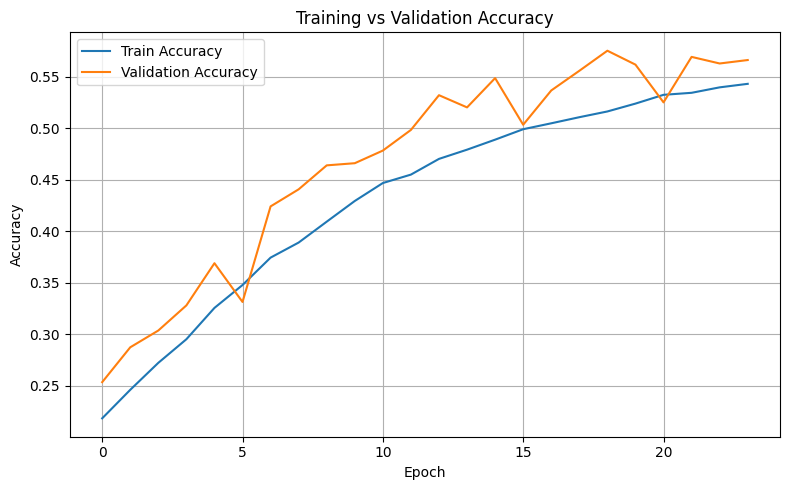

In [15]:
# Об'єднати історії по ключах
full_history = {}
for key in history.history:
    full_history[key] = history.history[key] + history2.history[key]

# Побудова графіків на основі full_history
plt.figure(figsize=(8, 5))
plt.plot(full_history['loss'], label='Train Loss')
plt.plot(full_history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(full_history['accuracy'], label='Train Accuracy')
plt.plot(full_history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:

eval_datagen = ImageDataGenerator(rescale=1./255)

eval_generator = eval_datagen.flow_from_directory(
    "test/",
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 7178 images belonging to 7 classes.


D:\ProgramFiles\Python3.10\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
D:\ProgramFiles\Python3.10\lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 110ms/step
Validation Accuracy: 0.5751
Class Names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


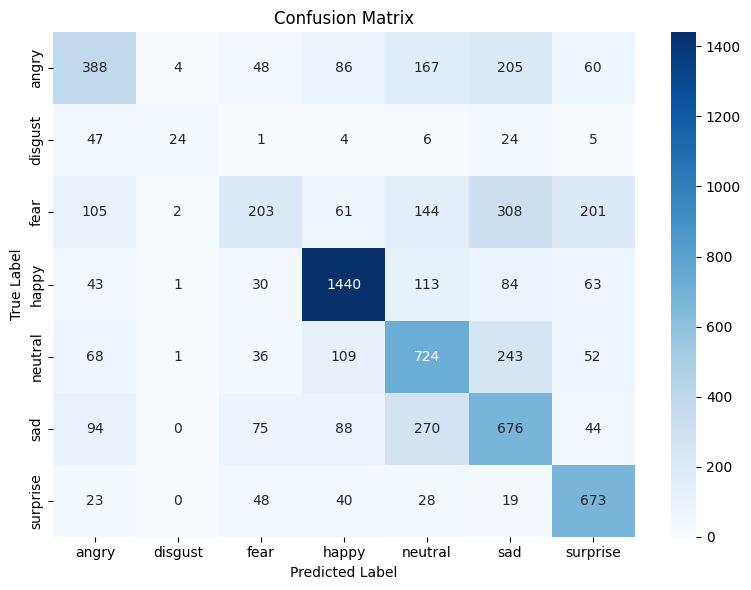

Classification Report:

              precision    recall  f1-score   support

       angry     0.5052    0.4050    0.4496       958
     disgust     0.7500    0.2162    0.3357       111
        fear     0.4603    0.1982    0.2771      1024
       happy     0.7877    0.8117    0.7996      1774
     neutral     0.4986    0.5872    0.5393      1233
         sad     0.4336    0.5421    0.4818      1247
    surprise     0.6129    0.8099    0.6978       831

    accuracy                         0.5751      7178
   macro avg     0.5783    0.5100    0.5115      7178
weighted avg     0.5713    0.5751    0.5595      7178



In [19]:
# --- ПЕРЕДБАЧЕННЯ ---
y_prob = model.predict(eval_generator)
y_pred = np.argmax(y_prob, axis=1)
y_true = eval_generator.classes

# --- ТОЧНІСТЬ ---
val_accuracy = accuracy_score(y_true, y_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

# --- КЛАСИ ---
class_indices = eval_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print("Class Names:", class_names)

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- CLASSIFICATION REPORT ---
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n")
print(report)